In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

**Data loading**

In [13]:
df = pd.read_csv('Train.csv')[['Path', 'ClassId']]

selected_classes = [0, 1, 2, 3, 5, 7]

#sample 100 images per selected class
filtered_df = pd.concat([
    df[df['ClassId'] == class_id].sample(100, random_state=42)
    for class_id in selected_classes
], ignore_index=True)

#Checking Counts Per class
print(filtered_df['ClassId'].value_counts())


ClassId
0    100
1    100
2    100
3    100
5    100
7    100
Name: count, dtype: int64


In [14]:
filtered_df['Path']

0      Train/0/00000_00001_00000.png
1      Train/0/00000_00005_00022.png
2      Train/0/00000_00002_00024.png
3      Train/0/00000_00006_00019.png
4      Train/0/00000_00002_00000.png
                   ...              
595    Train/7/00007_00013_00021.png
596    Train/7/00007_00013_00023.png
597    Train/7/00007_00040_00017.png
598    Train/7/00007_00034_00012.png
599    Train/7/00007_00005_00025.png
Name: Path, Length: 600, dtype: object

**Reading And Storing Images**

In [16]:
def read_image(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Image not found at path: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

image_data = []

for idx, row in filtered_df.iterrows():
    img_path = row['Path']
    img_array = read_image(img_path)
    label = row['ClassId']
    image_data.append((img_array, label))

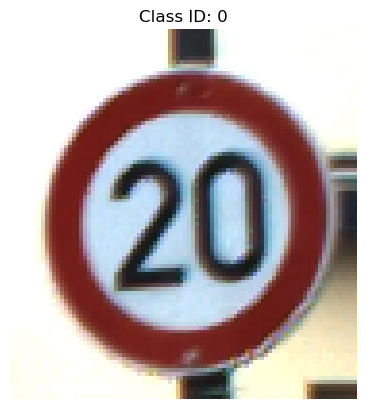

In [17]:
sample_img, sample_label = image_data[60]
plt.imshow(sample_img)
plt.title(f"Class ID: {sample_label}")
plt.axis('off')
plt.show()

In [9]:
sample_img, sample_label = image_data[20]
sample_img=cv2.imread('00000_00000_00020.png')
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
plt.imshow(sample_img)
plt.title(f"Class ID: {sample_label}")
plt.axis('off')
plt.show()

'sample_img, sample_label = image_data[20]\nsample_img=cv2.imread(\'00000_00000_00020.png\')\nsample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)\nplt.imshow(sample_img)\nplt.title(f"Class ID: {sample_label}")\nplt.axis(\'off\')\nplt.show()'

**Preprocessing And Filtering**

Mean Filter

In [18]:
# Function to apply the mean filter
def mean_filter(image, kernel_size=3):
    pad_size = kernel_size // 2
    padded_img = np.pad(image, ((pad_size, pad_size), (pad_size, pad_size), (0,0)), mode='edge')
    filtered_img = np.zeros_like(image)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            for c in range(3):  # For each color channel
                region = padded_img[y:y+kernel_size, x:x+kernel_size, c]
                filtered_img[y, x, c] = np.mean(region)
    
    return filtered_img.astype(np.uint8)

# Apply the mean filter to every image in your dataset
filtered_images_mean = []

for img, label in image_data:
    filtered_img = mean_filter(img)
    filtered_images_mean.append((filtered_img, label))



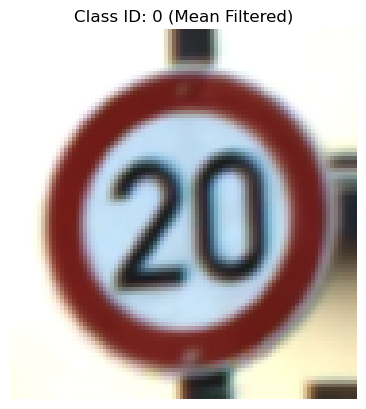

In [19]:
# Display one filtered image
sample_filtered_img, sample_label = filtered_images_mean[60]

plt.imshow(sample_filtered_img)
plt.title(f"Class ID: {sample_label} (Mean Filtered)")
plt.axis('off')
plt.show()

Gaussian

In [20]:
def gaussian_kernel(kernel_size=3, sigma=1):
    pad_size = kernel_size // 2
    # Create a 2D Gaussian kernel using the Gaussian function
    x = np.arange(-pad_size, pad_size + 1)
    x = np.exp(-0.5 * (x / sigma) ** 2)
    kernel = np.outer(x, x)  # Create the 2D Gaussian kernel by taking the outer product
    kernel = kernel / np.sum(kernel)  # Normalize the kernel to sum to 1 so brightness not affect
    return kernel

def gaussian_filter(image, kernel_size=3, sigma=1):
    pad_size = kernel_size // 2
    kernel = gaussian_kernel(kernel_size, sigma)  # Generate the Gaussian kernel
    padded_img = np.pad(image, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)), mode='edge')  # Padding for the image
    filtered_img = np.zeros_like(image)  # Initialize an output image

    # Convolve the image with the Gaussian kernel
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            for c in range(3):  # For each color channel (RGB)
                region = padded_img[y:y + kernel_size, x:x + kernel_size, c]  # Extract the region
                filtered_img[y, x, c] = np.sum(region * kernel)  # Convolve with the kernel

    return filtered_img.astype(np.uint8)  # Return the filtered image in uint8 format


In [21]:
filtered_images_gaussian = []
for img, label in filtered_images_mean: 
    filtered_img_gaussian = gaussian_filter(img, kernel_size=3, sigma=1) 
    filtered_images_gaussian.append((filtered_img_gaussian, label))

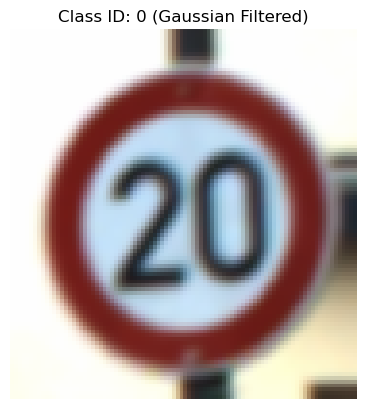

In [22]:
# Display the first image after applying the Gaussian filter
sample_filtered_img_gaussian, sample_label_gaussian = filtered_images_gaussian[60]
plt.imshow(sample_filtered_img_gaussian)
plt.title(f"Class ID: {sample_label_gaussian} (Gaussian Filtered)")
plt.axis('off')
plt.show()

# Median

In [23]:
def median_filter(image, kernel_size=3):
    pad_size = kernel_size // 2  
    padded_img = np.pad(image, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)), mode='edge') 
    filtered_img = np.zeros_like(image)  
    for y in range(image.shape[0]):  
        for x in range(image.shape[1]):
            for c in range(3):  
                region = padded_img[y:y+kernel_size, x:x+kernel_size, c]  
                filtered_img[y, x, c] = np.median(region)  

    return filtered_img.astype(np.uint8) 

filtered_images_median = []
for img, label in filtered_images_gaussian:  
    filtered_img_median = median_filter(img)
    filtered_images_median.append((filtered_img_median, label))

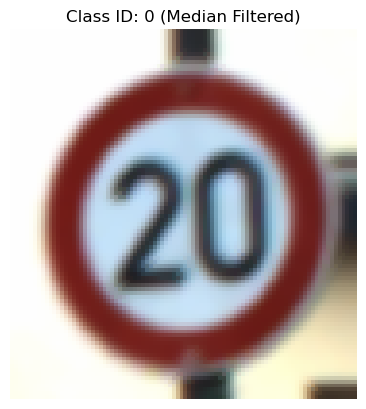

In [24]:
sample_filtered_img_median, sample_label_median = filtered_images_median[60]
plt.imshow(sample_filtered_img_median)
plt.title(f"Class ID: {sample_label_median} (Median Filtered)")
plt.axis('off')
plt.show()

# Median Filter

In [25]:
def adaptive_median_filter_level_ab(image, max_kernel_size=7):

    filtered_img = np.copy(image)
    pad_size = max_kernel_size // 2
    padded_img = np.pad(image, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)), mode='edge')
    
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            for c in range(3):  # RGB channels
                kernel_size = 3
                while kernel_size <= max_kernel_size:
                    half = kernel_size // 2
                    region = padded_img[y + pad_size - half : y + pad_size + half + 1,
                                        x + pad_size - half : x + pad_size + half + 1, c]
                    Zmin = np.min(region)
                    Zmax = np.max(region)
                    Zmed = np.median(region)
                    Zxy = padded_img[y + pad_size, x + pad_size, c]

                    A1 = Zmed - Zmin
                    A2 = Zmed - Zmax

                    if A1 > 0 and A2 < 0:
                        # Go to Level B
                        B1 = Zxy - Zmin
                        B2 = Zxy - Zmax
                        if B1 > 0 and B2 < 0:
                            filtered_img[y, x, c] = Zxy
                        else:
                            filtered_img[y, x, c] = Zmed
                        break  # Done with this pixel
                    else:
                        kernel_size += 2  # Increase window size
                else:
                    # Max kernel size exceeded
                    filtered_img[y, x, c] = Zmed
                    
    return filtered_img.astype(np.uint8)


In [26]:
filtered_images_adaptive_median = []
for img, label in filtered_images_median:  # Previous filtered_images list
    filtered_img = adaptive_median_filter_level_ab(img)
    filtered_images_adaptive_median.append((filtered_img, label))

C:\Users\Shekhani Laptops\AppData\Local\Temp\ipykernel_18408\2437486461.py:26: RuntimeWarning: overflow encountered in scalar subtract
  B2 = Zxy - Zmax


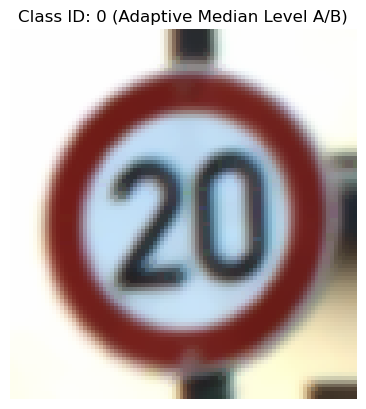

In [27]:
sample_img, sample_label = filtered_images_adaptive_median[60]
plt.imshow(sample_img)
plt.title(f"Class ID: {sample_label} (Adaptive Median Level A/B)")
plt.axis('off')
plt.show()

Unsharp Masking

In [28]:
def unsharp_masking_manual(image, kernel_size=3, sigma=1, alpha=1.5):
    image = image.astype(np.float32)
    blurred = gaussian_filter(image, kernel_size, sigma).astype(np.float32)
    mask = image - blurred
    sharpened = image + alpha * mask
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    return sharpened

In [29]:
sharpened_images = []

# Loop through filtered_images_adaptive_median and apply unsharp masking
for img, label in filtered_images_adaptive_median:
    sharpened_img = unsharp_masking_manual(img, kernel_size=3, sigma=1.0, alpha=1.5)
    sharpened_images.append((sharpened_img, label))


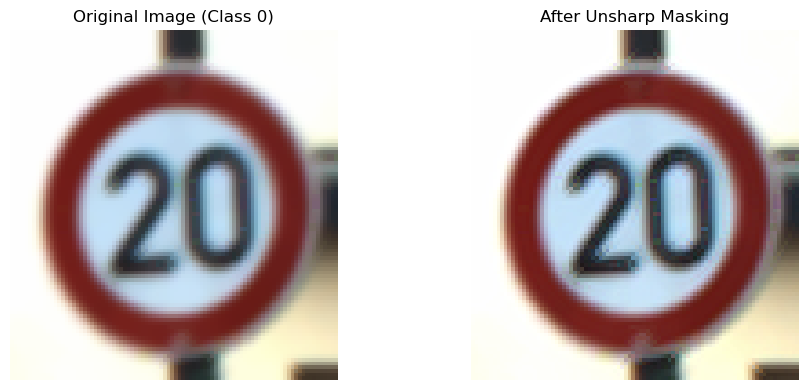

In [30]:
# Show one example of original vs sharpened image
sample_img, sample_label = filtered_images_adaptive_median[60]  # You can choose any index
sharpened_sample_img, _ = sharpened_images[60]  # Corresponding sharpened image

plt.figure(figsize=(10, 4))

# Original image
plt.subplot(1, 2, 1)
plt.title(f"Original Image (Class {sample_label})")
plt.imshow(sample_img)
plt.axis('off')

# Sharpened image
plt.subplot(1, 2, 2)
plt.title("After Unsharp Masking")
plt.imshow(sharpened_sample_img)
plt.axis('off')

plt.tight_layout()
plt.show()


**Part c**

In [31]:
def rgb_to_hsv(image):
    pil_image = Image.fromarray(image)  # Convert to PIL Image
    hsv_image = pil_image.convert("HSV")  # Convert to HSV
    hsv_image = np.array(hsv_image)  # Convert back to numpy array
    return hsv_image

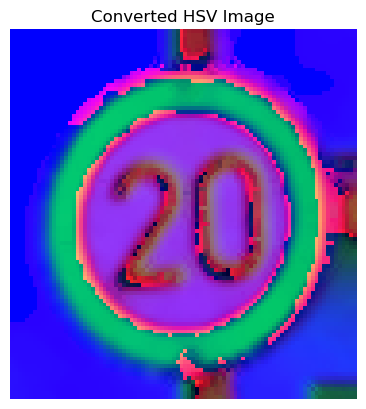

In [32]:
hehe = sample_img
sample_img_hsv = rgb_to_hsv(hehe)
plt.imshow(sample_img_hsv)
plt.title("Converted HSV Image")
plt.axis('off')
plt.show()

In [33]:
def segment_red_hsv(hsv_image):
    h, s, v = hsv_image[:, :, 0], hsv_image[:, :, 1], hsv_image[:, :, 2]

    # Red has two hue ranges in HSV space: [0–15] and [165–180]
    mask1 = (h >= 0) & (h <= 15)
    mask2 = (h >= 165) & (h <= 180)
    hue_mask = mask1 | mask2

    # Saturation and Value thresholds
    sat_mask = s >= 100
    val_mask = v >= 80

    # Combine all conditions
    red_mask = hue_mask & sat_mask & val_mask

    return red_mask.astype(np.uint8) * 255  # Return binary mask (0 or 255)


In [34]:
def segment_blue_hsv(hsv_image):
    h, s, v = hsv_image[:, :, 0], hsv_image[:, :, 1], hsv_image[:, :, 2]

    # Blue hue range: [100–130]
    blue_hue_mask = (h >= 100) & (h <= 130)

    # Saturation and Value thresholds
    sat_mask = s >= 100
    val_mask = v >= 80

    # Combine all conditions
    blue_mask = blue_hue_mask & sat_mask & val_mask

    return blue_mask.astype(np.uint8) * 255  # Return binary mask (0 or 255)


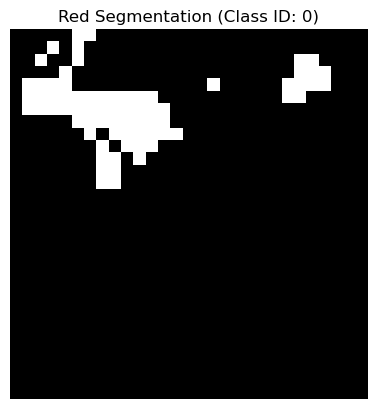

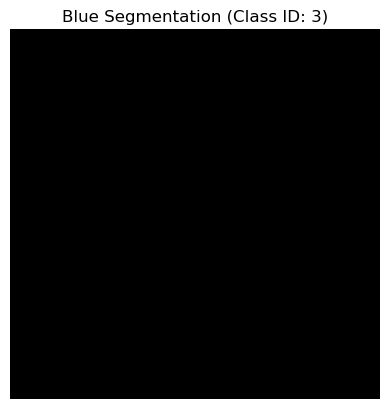

In [35]:

segmented_red_images = []
segmented_blue_images = []

for img, label in sharpened_images: 
    hsv_img = rgb_to_hsv(img) 
    

    red_mask = segment_red_hsv(hsv_img)
    blue_mask = segment_blue_hsv(hsv_img)
    

    red_pixel_count = np.sum(red_mask > 0)
    blue_pixel_count = np.sum(blue_mask > 0)
    
    if red_pixel_count > blue_pixel_count:
        segmented_red_images.append((red_mask, label)) 
    else:
        segmented_blue_images.append((blue_mask, label))  



sample_red_img, sample_red_label = segmented_red_images[0]
plt.imshow(sample_red_img, cmap='gray')
plt.title(f"Red Segmentation (Class ID: {sample_red_label})")
plt.axis('off')
plt.show()

# Example for Blue Sign Segmentation
sample_blue_img, sample_blue_label = segmented_blue_images[60]
plt.imshow(sample_blue_img, cmap='gray')
plt.title(f"Blue Segmentation (Class ID: {sample_blue_label})")
plt.axis('off')
plt.show()

**Part D Edge Detection**

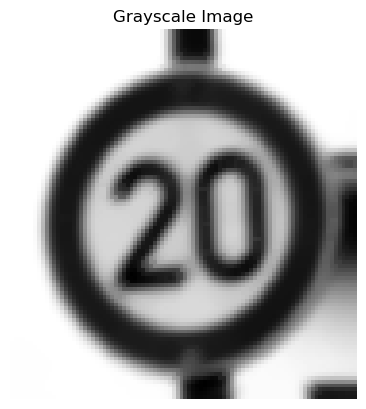

In [36]:
def rgb_to_grayscale(image):
    """
    Convert an RGB image to grayscale using the formula:
    grayscale = 0.2989 * R + 0.5870 * G + 0.1140 * B
    """
    grayscale_image = np.dot(image[...,:3], [0.2989, 0.5870, 0.1140])
    return grayscale_image

# Convert your sample image to grayscale
grayscale_image = rgb_to_grayscale(sample_img)

# Show grayscale image (optional)
import matplotlib.pyplot as plt
plt.imshow(grayscale_image, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()


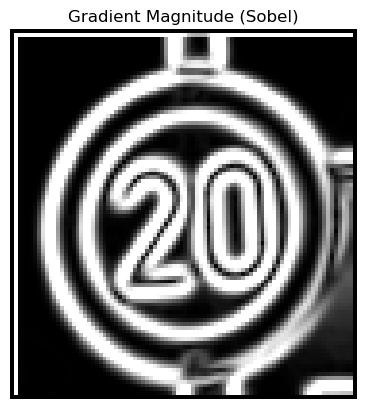

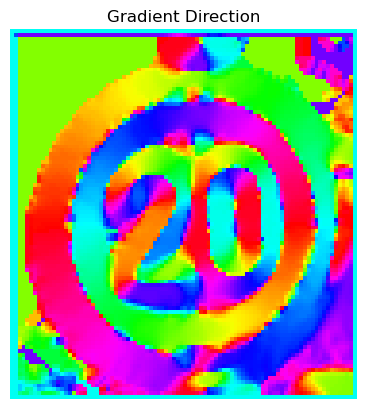

In [37]:
def sobel_edge_detection(image):
    """
    Compute the gradient magnitude and direction using Sobel operator.
    
    Parameters:
        image (2D np.array): Grayscale image.
    
    Returns:
        G (2D np.array): Gradient magnitude.
        theta (2D np.array): Gradient direction in radians.
    """
    # Sobel kernels for edge detection in X and Y directions
    sobel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.int32)

    sobel_y = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ], dtype=np.int32)

    # Pad the image to handle borders
    padded_image = np.pad(image, pad_width=1, mode='constant', constant_values=0)
    
    # Initialize gradient magnitude and direction arrays
    height, width = image.shape
    G = np.zeros_like(image, dtype=np.float32)  # Gradient magnitude
    theta = np.zeros_like(image, dtype=np.float32)  # Gradient direction
    
    # Apply Sobel operator to compute gradients
    for i in range(1, height - 1):
        for j in range(1, width - 1):
            region = padded_image[i-1:i+2, j-1:j+2]  # 3x3 region
            gx = np.sum(sobel_x * region)  # Gradient in x-direction
            gy = np.sum(sobel_y * region)  # Gradient in y-direction
            
            # Compute gradient magnitude and direction
            G[i, j] = np.sqrt(gx**2 + gy**2)
            theta[i, j] = np.arctan2(gy, gx)  # Direction in radians
    
    # Normalize gradient magnitude to 0-255 range for visualization
    G = np.clip(G, 0, 255)
    return G.astype(np.uint8), theta

# Convert your image to grayscale if not already done (use the function mentioned earlier)
grayscale_image = rgb_to_grayscale(sample_img)

# Compute Sobel edge detection
gradient_magnitude, gradient_direction = sobel_edge_detection(grayscale_image)

# Show the gradient magnitude for visualization
plt.imshow(gradient_magnitude, cmap='gray')
plt.title("Gradient Magnitude (Sobel)")
plt.axis('off')
plt.show()

# Gradient direction (optional for now)
plt.imshow(gradient_direction, cmap='hsv')
plt.title("Gradient Direction")
plt.axis('off')
plt.show()


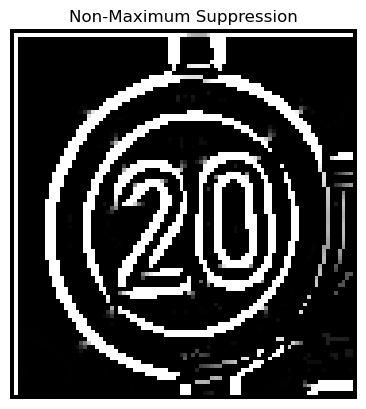

In [38]:
def non_maximum_suppression(G, theta):
    """
    Apply non-maximum suppression to thin the edges.
    
    Parameters:
        G (2D np.array): Gradient magnitude.
        theta (2D np.array): Gradient direction in radians.
    
    Returns:
        2D np.array: Thinned edges after NMS.
    """
    height, width = G.shape
    suppressed_image = np.zeros_like(G, dtype=np.uint8)
    
    # Convert theta to degrees
    angle = theta * 180.0 / np.pi
    angle[angle < 0] += 180  # Ensure angles are in the range [0, 180]

    for i in range(1, height - 1):
        for j in range(1, width - 1):
            # Get gradient direction
            direction = angle[i, j]
            
            # Compare the pixel with neighbors in the direction of the gradient
            if (0 <= direction < 22.5) or (157.5 <= direction <= 180):
                neighbor1 = G[i, j + 1]
                neighbor2 = G[i, j - 1]
            elif 22.5 <= direction < 67.5:
                neighbor1 = G[i + 1, j - 1]
                neighbor2 = G[i - 1, j + 1]
            elif 67.5 <= direction < 112.5:
                neighbor1 = G[i + 1, j]
                neighbor2 = G[i - 1, j]
            elif 112.5 <= direction < 157.5:
                neighbor1 = G[i - 1, j - 1]
                neighbor2 = G[i + 1, j + 1]

            # Keep the current pixel only if it's a local maximum
            if G[i, j] >= neighbor1 and G[i, j] >= neighbor2:
                suppressed_image[i, j] = G[i, j]
            else:
                suppressed_image[i, j] = 0

    return suppressed_image

# Apply Non-Maximum Suppression on the gradient magnitude and direction
nms_result = non_maximum_suppression(gradient_magnitude, gradient_direction)

# Show the result of Non-Maximum Suppression
plt.imshow(nms_result, cmap='gray')
plt.title("Non-Maximum Suppression")
plt.axis('off')
plt.show()


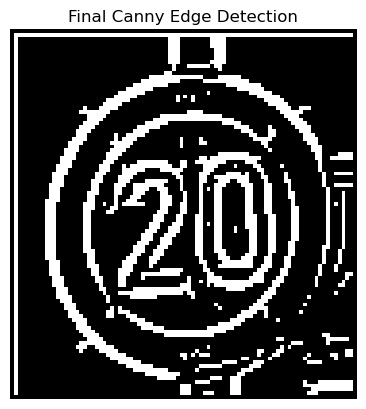

In [39]:
def double_thresholding_and_edge_tracking(G, low_threshold, high_threshold):
    """
    Perform double thresholding and edge tracking by hysteresis.
    
    Parameters:
        G (2D np.array): Gradient magnitude after Non-Maximum Suppression.
        low_threshold (int): Lower threshold for weak edges.
        high_threshold (int): Upper threshold for strong edges.
    
    Returns:
        2D np.array: Final binary edge map after double thresholding and hysteresis.
    """
    height, width = G.shape
    output_image = np.zeros_like(G, dtype=np.uint8)
    
    # Strong edges are those above high_threshold
    strong_edges = (G > high_threshold)
    # Weak edges are those between low_threshold and high_threshold
    weak_edges = (G >= low_threshold) & (G <= high_threshold)
    
    # Mark the strong edges as 255 (white)
    output_image[strong_edges] = 255
    
    # Iterate through weak edges and perform edge tracking by hysteresis
    for i in range(1, height - 1):
        for j in range(1, width - 1):
            if weak_edges[i, j]:
                # Check if the weak edge is connected to a strong edge
                if np.any(strong_edges[i - 1:i + 2, j - 1:j + 2]):  # Check 3x3 neighborhood
                    output_image[i, j] = 255  # Retain weak edge if connected to strong edge
                else:
                    output_image[i, j] = 0  # Otherwise discard weak edge
    
    return output_image

# Set thresholds (you can adjust these values based on the results)
low_threshold = 10
high_threshold = 10

# Apply double thresholding and edge tracking
final_edges = double_thresholding_and_edge_tracking(nms_result, low_threshold, high_threshold)

# Show the final result after Double Thresholding and Edge Tracking
plt.imshow(final_edges, cmap='gray')
plt.title("Final Canny Edge Detection")
plt.axis('off')
plt.show()


Part c new trial 

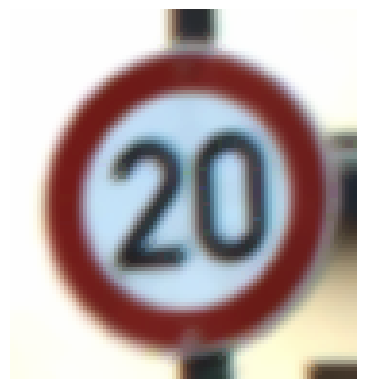

In [40]:
def rgb_to_hsv(image):
    pil_image = Image.fromarray(image)  # RGB image
    hsv_image = pil_image.convert("HSV")
    return np.array(hsv_image)

# Convert
sample_img_hsv = rgb_to_hsv(sample_img)

# Convert back to RGB for display
hsv_pil = Image.fromarray(sample_img_hsv, mode='HSV')
rgb_back = np.array(hsv_pil.convert("RGB"))

# Show the corrected image
plt.imshow(rgb_back)
plt.axis('off')
plt.show()


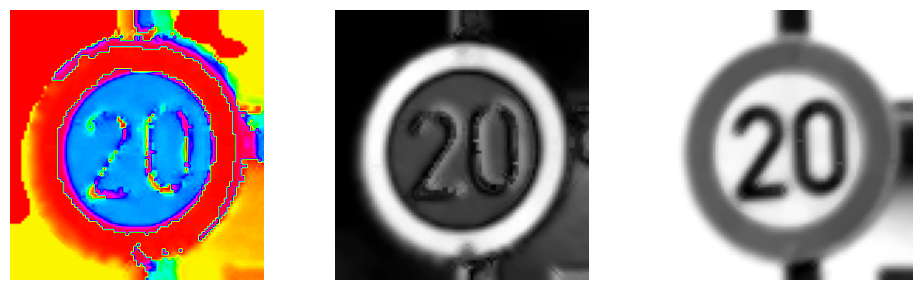

In [41]:
h, s, v = sample_img_hsv[:, :, 0], sample_img_hsv[:, :, 1], sample_img_hsv[:, :, 2]

plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
plt.imshow(h, cmap='hsv')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(s, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(v, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


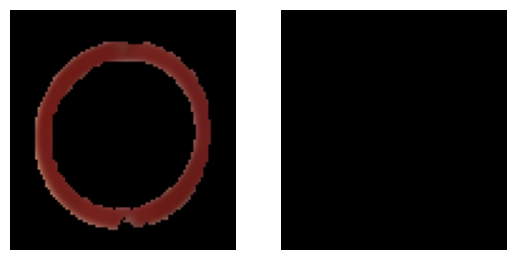

In [42]:
red_mask1 = ((h >= 0) & (h <= 10)) & (s >= 100) & (v >= 80)
red_mask2 = ((h >= 117) & (h <= 127)) & (s >= 100) & (v >= 80)
red_mask = red_mask1 | red_mask2

# Blue sign mask: Hue in [71–92], Sat >= 100, Val >= 80
blue_mask = ((h >= 71) & (h <= 92)) & (s >= 100) & (v >= 80)

# Apply masks
segmented_red = np.zeros_like(sample_img)
segmented_red[red_mask] = sample_img[red_mask]

segmented_blue = np.zeros_like(sample_img)
segmented_blue[blue_mask] = sample_img[blue_mask]

# Show results side by side
plt.subplot(1, 2, 1)
plt.imshow(segmented_red)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_blue)
plt.axis('off')

plt.show()

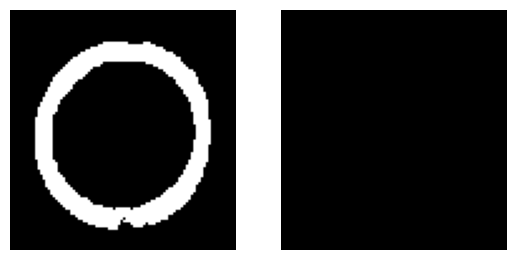

In [43]:
binary_red = np.uint8(red_mask) * 255
binary_blue = np.uint8(blue_mask) * 255

# Display binary masks
plt.subplot(1, 2, 1)
plt.imshow(binary_red, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_blue, cmap='gray')
plt.axis('off')

plt.show()

In [44]:
def erosion(binary_img):
    padded = np.pad(binary_img, pad_width=1, mode='constant', constant_values=0)
    result = np.zeros_like(binary_img)
    for i in range(1, padded.shape[0]-1):
        for j in range(1, padded.shape[1]-1):
            region = padded[i-1:i+2, j-1:j+2]
            if np.all(region == 255):
                result[i-1, j-1] = 255
    return result

In [45]:
def dilation(binary_img):
    padded = np.pad(binary_img, pad_width=1, mode='constant', constant_values=0)
    result = np.zeros_like(binary_img)
    for i in range(1, padded.shape[0]-1):
        for j in range(1, padded.shape[1]-1):
            region = padded[i-1:i+2, j-1:j+2]
            if np.any(region == 255):
                result[i-1, j-1] = 255
    return result

In [46]:
def opening(binary_img):
    return dilation(erosion(binary_img))

In [47]:
def connected_component_filter(binary_img, min_area=150):
    h, w = binary_img.shape
    visited = np.zeros_like(binary_img, dtype=bool)
    output = np.zeros_like(binary_img)

    label = 1
    for i in range(h):
        for j in range(w):
            if binary_img[i, j] == 255 and not visited[i, j]:
                # Start flood fill
                stack = [(i, j)]
                coords = []

                while stack:
                    x, y = stack.pop()
                    if (0 <= x < h and 0 <= y < w and 
                        binary_img[x, y] == 255 and not visited[x, y]):
                        visited[x, y] = True
                        coords.append((x, y))
                        stack.extend([(x-1,y), (x+1,y), (x,y-1), (x,y+1)])

                if len(coords) >= min_area:
                    for x, y in coords:
                        output[x, y] = 255
    return output


In [48]:
def fill_holes(binary_img):
    h, w = binary_img.shape
    filled = binary_img.copy()
    visited = np.zeros((h, w), dtype=bool)

    stack = [(0, 0)]
    while stack:
        x, y = stack.pop()
        if 0 <= x < h and 0 <= y < w:
            if filled[x, y] == 0 and not visited[x, y]:
                visited[x, y] = True
                filled[x, y] = 128  # temporary fill value
                stack.extend([(x-1,y), (x+1,y), (x,y-1), (x,y+1)])

    # Invert to fill holes
    result = np.where(filled == 0, 255, 0)
    return result.astype(np.uint8)


In [49]:
def post_process(binary_mask):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    steps = []

    opened = opening(binary_mask)
    steps.append(('Opening', opened))

    filtered = connected_component_filter(opened)
    steps.append(('After Filtering', filtered))

    filled = fill_holes(filtered)
    steps.append(('Hole Filled', filled))

    steps.insert(0, ('Original', binary_mask))

    for ax, (title, img) in zip(axes, steps):
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    return filled

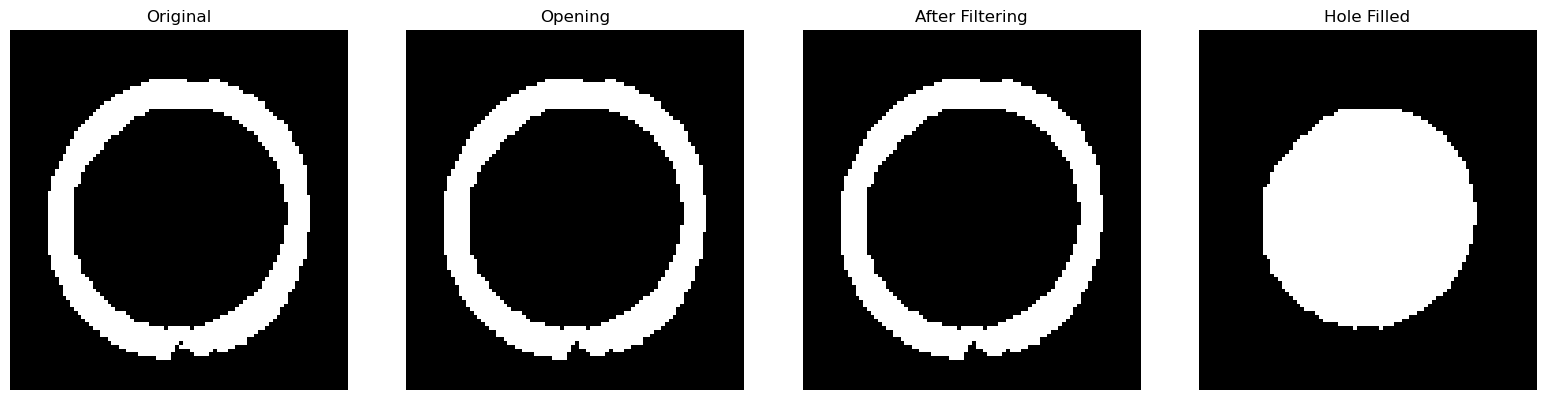

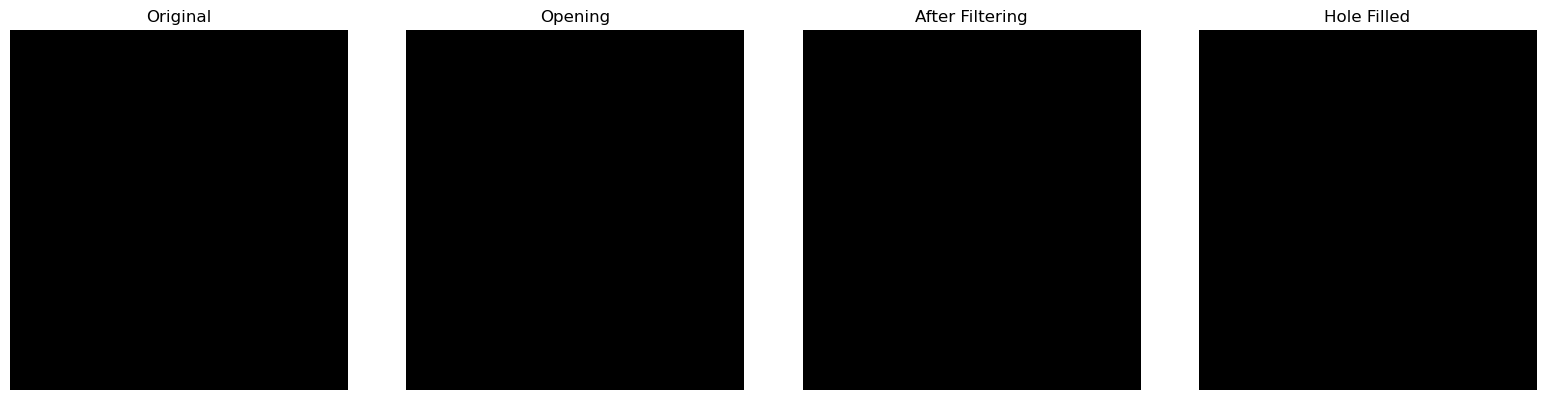

In [50]:
processed_red = post_process(binary_red)
processed_blue = post_process(binary_blue)

# Part E-1

In [56]:
def get_rotation_matrix(angle_deg, center):
    angle_rad = np.deg2rad(angle_deg)
    cos_a = np.cos(angle_rad)
    sin_a = np.sin(angle_rad)
    cx, cy = center
    R = np.array([
        [cos_a, -sin_a, cx - cos_a * cx + sin_a * cy],
        [sin_a,  cos_a, cy - sin_a * cx - cos_a * cy],
        [0,      0,     1]
    ])
    return R

def get_scaling_matrix(scale_x, scale_y, center):
    cx, cy = center
    S = np.array([
        [scale_x, 0,      cx - scale_x * cx],
        [0,      scale_y, cy - scale_y * cy],
        [0,      0,       1]
    ])
    return S

def affine_transform(image, M, output_shape):
    h_out, w_out = output_shape
    h_in, w_in = image.shape[:2]
    inv_M = np.linalg.inv(M)

    output = np.zeros((h_out, w_out, image.shape[2]), dtype=image.dtype)

    yy, xx = np.meshgrid(np.arange(h_out), np.arange(w_out), indexing='ij')
    ones = np.ones_like(xx)
    coords = np.stack([xx, yy, ones], axis=-1).reshape(-1, 3).T

    src_coords = inv_M @ coords
    src_x = np.round(src_coords[0, :]).astype(int).reshape(h_out, w_out)
    src_y = np.round(src_coords[1, :]).astype(int).reshape(h_out, w_out)

    valid = (src_x >= 0) & (src_x < w_in) & (src_y >= 0) & (src_y < h_in)

    for c in range(image.shape[2]):
        output[..., c][valid] = image[src_y[valid], src_x[valid], c]

    return output

def rotate_and_scale_image(image, angle_deg, output_size=(200, 200)):
    h, w = image.shape[:2]
    center = (w / 2, h / 2)

    # Rotation matrix
    R = get_rotation_matrix(angle_deg, center)

    # Scaling factors to get output_size
    scale_x = output_size[1] / w
    scale_y = output_size[0] / h
    S = get_scaling_matrix(scale_x, scale_y, center)

    # Combined affine matrix: scale after rotation
    M = S @ R

    # Apply affine transform
    transformed_img = affine_transform(image, M, output_size)
    return transformed_img


In [57]:
print("Image after scaling and rotation:")
Scaledimg = rotate_and_scale_image(sample_img,90,(200,200))

Image after scaling and rotation:


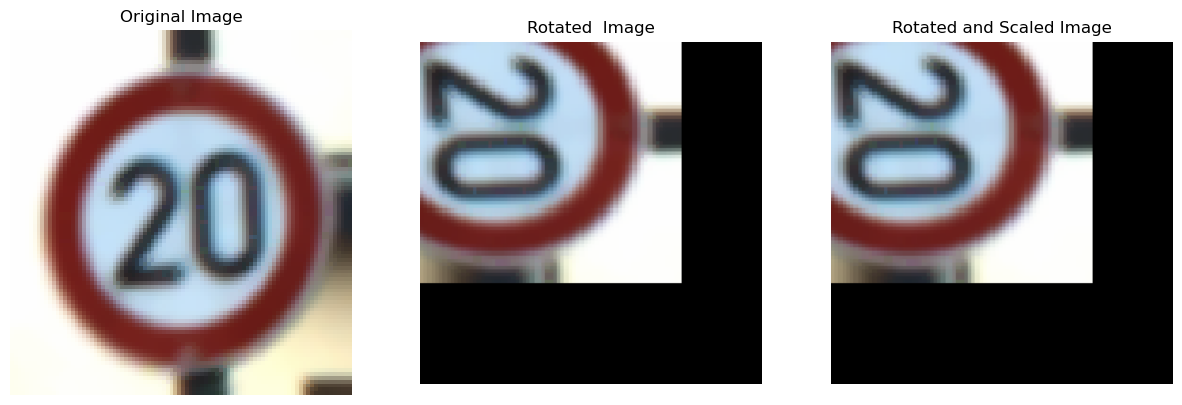

In [58]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(sample_img)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Rotated  Image")
plt.imshow(rotated_img)
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Rotated and Scaled Image")
plt.imshow(Scaledimg)
plt.axis('off')
plt.show()

# Part F

In [427]:
def normalize_image(image):
    """Normalize image to 0-1 range"""
    return (image - np.min(image)) / (np.max(image) - np.min(image))

def harris_corner_detection(image, k=0.04, window_size=3, threshold=0.01):
    # Convert to float if needed
    image = image.astype(np.float32)
    
    # Compute gradients
    Ix = np.gradient(image, axis=1)
    Iy = np.gradient(image, axis=0)
    
    # Compute products of gradients
    Ixx = Ix**2
    Iyy = Iy**2
    Ixy = Ix * Iy
    
    # Sum over window (simple box filter)
    Sxx = np.zeros_like(image)
    Syy = np.zeros_like(image)
    Sxy = np.zeros_like(image)
    
    offset = window_size // 2
    for i in range(offset, image.shape[0]-offset):
        for j in range(offset, image.shape[1]-offset):
            Sxx[i,j] = np.sum(Ixx[i-offset:i+offset+1, j-offset:j+offset+1])
            Syy[i,j] = np.sum(Iyy[i-offset:i+offset+1, j-offset:j+offset+1])
            Sxy[i,j] = np.sum(Ixy[i-offset:i+offset+1, j-offset:j+offset+1])
    
    # Compute determinant and trace
    det = Sxx * Syy - Sxy**2
    trace = Sxx + Syy
    
    # Compute corner response
    R = det - k * trace**2
    
    # Threshold and count corners
    corners = R > threshold * R.max()
    corner_count = np.sum(corners)
    
    # Get corner coordinates
    corner_coords = np.argwhere(corners)
    
    return corner_count, corner_coords

def find_contours(binary_image):
    # Pad the image to handle borders
    padded = np.pad(binary_image, pad_width=1, mode='constant', constant_values=0)
    
    contours = []
    visited = np.zeros_like(padded, dtype=bool)
    
    # 8-connectivity directions
    directions = [(-1, -1), (-1, 0), (-1, 1),
                  (0, -1),          (0, 1),
                  (1, -1),  (1, 0), (1, 1)]
    
    for i in range(1, padded.shape[0]-1):
        for j in range(1, padded.shape[1]-1):
            if padded[i,j] == 1 and not visited[i,j]:
                # New contour found
                contour = []
                queue = [(i,j)]
                visited[i,j] = True
                
                while queue:
                    x, y = queue.pop(0)
                    contour.append((x-1, y-1))  # Adjust for padding
                    
                    for dx, dy in directions:
                        nx, ny = x + dx, y + dy
                        if (padded[nx,ny] == 1 and not visited[nx,ny]):
                            visited[nx,ny] = True
                            queue.append((nx, ny))
                
                contours.append(np.array(contour))
    
    return contours

def calculate_circularity(contour):
    """Calculate circularity from contour points"""
    if len(contour) < 3:
        return 0.0
    
    # Calculate area using shoelace formula
    x = contour[:,1]
    y = contour[:,0]
    area = 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))
    
    # Calculate perimeter
    perimeter = 0.0
    for i in range(len(contour)):
        dx = contour[(i+1)%len(contour)][1] - contour[i][1]
        dy = contour[(i+1)%len(contour)][0] - contour[i][0]
        perimeter += np.sqrt(dx**2 + dy**2)
    
    if perimeter == 0:
        return 0.0
    
    circularity = (4 * np.pi * area) / (perimeter ** 2)
    return circularity

def calculate_aspect_ratio(contour):
    """Calculate aspect ratio from contour points"""
    if len(contour) == 0:
        return 0.0
    
    x = contour[:,1]
    y = contour[:,0]
    min_x, max_x = np.min(x), np.max(x)
    min_y, max_y = np.min(y), np.max(y)
    
    width = max_x - min_x
    height = max_y - min_y
    
    if height == 0:
        return 0.0
    
    return width / height

def calculate_extent(contour):
    """Calculate extent (area / bounding box area) from contour points"""
    if len(contour) < 3:
        return 0.0
    
    # Calculate area using shoelace formula
    x = contour[:,1]
    y = contour[:,0]
    area = 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))
    
    # Calculate bounding box area
    min_x, max_x = np.min(x), np.max(x)
    min_y, max_y = np.min(y), np.max(y)
    bbox_area = (max_x - min_x) * (max_y - min_y)
    
    if bbox_area == 0:
        return 0.0
    
    return area / bbox_area

def calculate_average_hue(image, contour=None):
    """Calculate average hue from RGB image (0-360 degrees)"""
    # Convert RGB to HSV manually
    r, g, b = image[:,:,0], image[:,:,1], image[:,:,2]
    r, g, b = r/255.0, g/255.0, b/255.0  # Normalize to 0-1
    cmax = np.maximum(np.maximum(r, g), b)
    cmin = np.minimum(np.minimum(r, g), b)
    delta = cmax - cmin
    # Calculate hue
    hue = np.zeros_like(cmax)
    mask = delta != 0
    # Cases for hue calculation
    case1 = (cmax == r) & mask
    case2 = (cmax == g) & mask
    case3 = (cmax == b) & mask
    hue[case1] = 60 * (((g - b)/delta) % 6)[case1]
    hue[case2] = 60 * (((b - r)/delta) + 2)[case2]
    hue[case3] = 60 * (((r - g)/delta) + 4)[case3]
    # If contour is provided, mask the image
    if contour is not None and len(contour) > 0:
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=bool)
        for point in contour:
            if 0 <= point[0] < mask.shape[0] and 0 <= point[1] < mask.shape[1]:
                mask[point[0], point[1]] = True
        hue = hue[mask]
    # Calculate average hue (avoid NaN values)
    valid_hues = hue[np.isfinite(hue)]
    if len(valid_hues) == 0:
        return 0.0
    return np.mean(valid_hues) % 360  # Ensure hue is within 0-360

def extract_features(image):
    if image.dtype == np.float32 or image.dtype == np.float64:
        image = (image * 255).astype(np.uint8)
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        gray = np.mean(image, axis=2).astype(np.uint8)
    else:
        gray = image
    # Normalize image
    normalized = normalize_image(gray)
    # Feature dictionary
    features = {}
    # 1. Corner Count (Harris Corner Detection)
    corner_count, _ = harris_corner_detection(normalized)
    features['corner_count'] = corner_count
    # 2. Create binary image for contour-based features
    threshold = np.mean(normalized)
    binary = (normalized > threshold).astype(np.uint8)
    # Find contours
    contours = find_contours(binary)
    if len(contours) > 0:
        # Use largest contour
        largest_contour = max(contours, key=lambda c: len(c))
        # 2. Circularity
        features['circularity'] = calculate_circularity(largest_contour)
        # 3. Aspect Ratio
        features['aspect_ratio'] = calculate_aspect_ratio(largest_contour)
        # 4. Extent
        features['extent'] = calculate_extent(largest_contour)
        # 5. Average Hue (use original color image)
        features['average_hue'] = calculate_average_hue(image, largest_contour)
    else:
        features['circularity'] = 0.0
        features['aspect_ratio'] = 0.0
        features['extent'] = 0.0
        features['average_hue'] = calculate_average_hue(image)
    
    return features

In [428]:
features=extract_features(sample_img)
df = pd.DataFrame([features])
print("Extracted Features:")
print(df.transpose())

Extracted Features:
                       0
corner_count  434.000000
circularity     0.000554
aspect_ratio    0.452632
extent          0.250673
average_hue    35.329764


C:\Users\Shekhani Laptops\AppData\Local\Temp\ipykernel_18408\761769581.py:168: RuntimeWarning: invalid value encountered in divide
  hue[case1] = 60 * (((g - b)/delta) % 6)[case1]
C:\Users\Shekhani Laptops\AppData\Local\Temp\ipykernel_18408\761769581.py:169: RuntimeWarning: invalid value encountered in divide
  hue[case2] = 60 * (((b - r)/delta) + 2)[case2]
C:\Users\Shekhani Laptops\AppData\Local\Temp\ipykernel_18408\761769581.py:170: RuntimeWarning: invalid value encountered in divide
  hue[case3] = 60 * (((r - g)/delta) + 4)[case3]


In [429]:
features_list = []
for img_data, klass in image_data:
    features = extract_features(img_data)
    features['class'] = klass
    features_list.append(features)
data = pd.DataFrame(features_list)

C:\Users\Shekhani Laptops\AppData\Local\Temp\ipykernel_18408\761769581.py:168: RuntimeWarning: invalid value encountered in divide
  hue[case1] = 60 * (((g - b)/delta) % 6)[case1]
C:\Users\Shekhani Laptops\AppData\Local\Temp\ipykernel_18408\761769581.py:169: RuntimeWarning: invalid value encountered in divide
  hue[case2] = 60 * (((b - r)/delta) + 2)[case2]
C:\Users\Shekhani Laptops\AppData\Local\Temp\ipykernel_18408\761769581.py:170: RuntimeWarning: invalid value encountered in divide
  hue[case3] = 60 * (((r - g)/delta) + 4)[case3]


In [430]:
data

,corner_count,circularity,aspect_ratio,extent,average_hue,class
0,428,0.003143,1.136364,0.198182,164.035582,0
1,205,0.001386,1.195652,0.849802,111.790425,0
2,195,0.000562,0.492754,0.177536,137.384697,0
3,326,0.003422,1.000000,0.917820,72.271970,0
4,236,0.017973,1.083333,0.307692,247.624706,0
...,...,...,...,...,...,...
595,318,0.002858,1.194444,0.836886,68.405793,7
596,316,0.001205,1.042553,0.498697,99.029099,7
597,191,0.005123,1.272727,0.931818,237.721633,7
598,84,0.006261,1.000000,0.788280,217.208530,7


# Part G

In [254]:
class_names=["0.png","1.png","2.png","3.png","5.png","7.png"]
image_data_y=[]
for k in class_names:
    path="Meta/"+k
    img_array = read_image(path)
    image_data_y.append(img_array)

In [255]:
features_list_y=[]
for a in range(len(image_data_y)):
    features = extract_features(image_data_y[a])
    features['class'] = selected_classes[a]
    features_list_y.append(features)
data_2=pd.DataFrame(features_list_y)

C:\Users\Shekhani Laptops\AppData\Local\Temp\ipykernel_18408\761769581.py:168: RuntimeWarning: invalid value encountered in divide
  hue[case1] = 60 * (((g - b)/delta) % 6)[case1]
C:\Users\Shekhani Laptops\AppData\Local\Temp\ipykernel_18408\761769581.py:169: RuntimeWarning: invalid value encountered in divide
  hue[case2] = 60 * (((b - r)/delta) + 2)[case2]
C:\Users\Shekhani Laptops\AppData\Local\Temp\ipykernel_18408\761769581.py:170: RuntimeWarning: invalid value encountered in divide
  hue[case3] = 60 * (((r - g)/delta) + 4)[case3]


In [256]:
data_2

,corner_count,circularity,aspect_ratio,extent,average_hue,class
0,529,0.000066,1.0,0.092133,0.369387,0
1,568,0.000048,1.0,0.064813,0.369204,1
2,534,0.000026,1.0,0.034850,0.368292,2
3,523,0.000018,1.0,0.023153,0.384578,3
4,510,0.000128,1.0,0.163916,0.390708,5
5,554,0.002736,1.0,3.797548,0.422294,7


In [413]:
class TrafficSignClassifier:
    def __init__(self):
        self.training_features = []
        self.training_labels = []
        self.feature_min = {}
        self.feature_max = {}

    def train(self, X_train, y_train):
        if not isinstance(X_train, pd.DataFrame):
            X_train = pd.DataFrame(X_train)
        self.training_features = []
        self.training_labels = list(y_train)
        self.feature_min = X_train.min().to_dict()
        self.feature_max = X_train.max().to_dict()
        for k in self.feature_min:
            self.feature_min[k] = float(self.feature_min[k])
            self.feature_max[k] = float(self.feature_max[k])
        for _, row in X_train.iterrows():
            self.training_features.append(row.to_dict())

    def normalize_features(self, features):
        normalized = {}
        for key, value in features.items():
            min_val = self.feature_min.get(key)
            max_val = self.feature_max.get(key)
            if min_val is not None and max_val is not None and max_val != min_val:
                norm_val = (value - min_val) / (max_val - min_val)
            else:
                norm_val = value
            normalized[key] = norm_val
        return normalized

    def classify(self, features):
        norm_features = self.normalize_features(features)
        best_distance = float('inf')
        best_label = None
        for train_feat, train_label in zip(self.training_features, self.training_labels):
            dist = 0.0
            for key, val in norm_features.items():
                train_val = train_feat.get(key)
                if isinstance(train_val, (float, int)):
                    dist += (val - train_val) ** 2
            if dist < best_distance:
                best_distance = dist
                best_label = train_label
        return best_label

    def rule_based_classify(self, features):
        corners = features.get('corner_count', 0)
        circularity = features.get('circularity', 0)
        aspect = features.get('aspect_ratio', 0)
        extent = features.get('extent', 0)
        hue = features.get('average_hue', 0)

        # Edge case: White bar detection (high extent, low circularity, high hue)
        if extent > 3.0 and circularity < 0.003 and hue > 0.4:
            return 7  # Class 7 (white bar)
        
        # Color-based rules first
        if hue > 0.4:
            # High hue objects (yellowish)
            if circularity > 0.002:
                return 7  # Class 7
            elif extent > 0.15:
                return 5  # Class 5
            else:
                return 3  # Class 3
        
        # Shape-based classification hierarchy
        if circularity < 0.00002:
            if extent < 0.025:
                return 3  # Class 3 (most compact)
            elif extent < 0.04:
                return 2  # Class 2
            else:
                return 1  # Class 1
        elif circularity < 0.00005:
            if extent < 0.07:
                return 1  # Class 1
            else:
                return 0  # Class 0
        elif circularity < 0.0001:
            if extent < 0.12:
                return 0  # Class 0
            else:
                return 5  # Class 5
        elif circularity < 0.001:
            return 5  # Class 5
        else:
            return 7  # Class 7 (highest circularity)

    def evaluate_with_mode(self, X_test, y_test, mode='nn'):
        correct = 0
        total = 0
        for i, (_, row) in enumerate(X_test.iterrows()):
            features = row.to_dict()
            pred = self.classify(features) if mode == 'nn' else self.rule_based_classify(features)
            if i < len(y_test) and pred == y_test[i]:
                correct += 1
            total += 1
        return correct / total if total > 0 else 0

    def predict_dataframe(self, X_df, mode='nn'):
        predictions = []
        for _, row in X_df.iterrows():
            features = row.to_dict()
            if mode == 'nn':
                pred = self.classify(features)
            else:
                pred = self.rule_based_classify(features)
            predictions.append(pred)
        return predictions

In [414]:
feature_cols=['corner_count', 'circularity', 'aspect_ratio', 'extent', 'average_hue']
X = data[feature_cols]
y = data['class']
# Initialize and train
model = TrafficSignClassifier()
model.train(X, y)

In [415]:
rule_acc = model.evaluate_with_mode(X, y, mode='rule')
print(f"Rule-Based Accuracy: {rule_acc:.2f}")

Rule-Based Accuracy: 0.17


# Model

In [482]:
class BoostedTree:
    def __init__(self, n_top_features=5):
        self.n_top_features = n_top_features
        self.selected_features = []
        self.model = GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.9,
            random_state=42
        )

    def select_top_correlated_features(self, X, y):
        df = X.copy()
        df['label'] = y
        correlations = df.corr()['label'].drop('label').abs()
        self.selected_features = correlations.sort_values(ascending=False).head(self.n_top_features).index.tolist()

    def train(self, X, y):
        self.select_top_correlated_features(X, y)
        X_selected = X[self.selected_features]
        self.model.fit(X_selected, y)

    def predict(self, X):
        return self.model.predict(X[self.selected_features])

    def evaluate(self, X_test, y_test):
        preds = self.predict(X_test)
        return accuracy_score(y_test, preds)

In [483]:
train_idx, test_idx = train_test_split(data.index, test_size=0.3, random_state=42)
model_3=BoostedTree(n_top_features=5)
X_train = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]
model_3.train(X_train, y_train)
predictions=model_3.predict(X_test)

# Evaluation

In [480]:

def evaluate_per_class_metrics(actual_labels, predicted_labels, category_list):
    # Initialize a dictionary to keep track of TP, FP, TN, FN for every class
    stats_per_class = {
        category: {'TP': 0, 'FP': 0, 'TN': 0, 'FN': 0} for category in category_list
    }
    
    # Total number of data points
    sample_count = len(actual_labels)
    
    # Go through each prediction and update the confusion statistics for each class
    for actual, predicted in zip(actual_labels, predicted_labels):
        for category in category_list:
            if actual == category:
                if predicted == category:
                    stats_per_class[category]['TP'] += 1  # Correct prediction for this class
                else:
                    stats_per_class[category]['FN'] += 1  # Missed this class (should have predicted it)
            else:
                if predicted == category:
                    stats_per_class[category]['FP'] += 1  # Incorrectly predicted this class
                else:
                    stats_per_class[category]['TN'] += 1  # Correctly did not predict this class
    
    # Prepare lists to aggregate metrics across all classes
    accuracy_list = []
    precision_list = []
    recall_list = []
    
    # Calculate and print metrics for each class
    for category in category_list:
        TP = stats_per_class[category]['TP']
        FP = stats_per_class[category]['FP']
        TN = stats_per_class[category]['TN']
        FN = stats_per_class[category]['FN']
        
        # Compute metrics, handling division by zero
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        accuracy = (TP + TN) / sample_count if sample_count > 0 else 0
        
        # Store metrics for overall summary
        accuracy_list.append(accuracy)
        precision_list.append(precision)
        recall_list.append(recall)
        
        # Display metrics for this class
        print(f"Class '{category}':")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  Accuracy:  {accuracy:.4f}")
        print("-" * 32)
    
    # Print average metrics across all classes
    print(f"Overall Accuracy:  {np.mean(accuracy_list):.4f}")
    print(f"Overall Recall:    {np.mean(recall_list):.4f}")
    print(f"Overall Precision: {np.mean(precision_list):.4f}")


In [481]:
evaluate_per_class_metrics(y_test, predictions, selected_classes)

Class '0':
  Precision: 0.5385
  Recall:    0.5526
  Accuracy:  0.8056
--------------------------------
Class '1':
  Precision: 0.2222
  Recall:    0.1935
  Accuracy:  0.7444
--------------------------------
Class '2':
  Precision: 0.3200
  Recall:    0.2759
  Accuracy:  0.7889
--------------------------------
Class '3':
  Precision: 0.2500
  Recall:    0.2917
  Accuracy:  0.7889
--------------------------------
Class '5':
  Precision: 0.3333
  Recall:    0.4400
  Accuracy:  0.8000
--------------------------------
Class '7':
  Precision: 0.3929
  Recall:    0.3333
  Accuracy:  0.7833
--------------------------------
Overall Accuracy:  0.7852
Overall Recall:    0.3478
Overall Precision: 0.3428


In [475]:

def display_confusion_matrix(actual_labels, predicted_labels, categories):
    # Determine the number of unique classes
    total_classes = len(categories)
    
    # Create an empty matrix for confusion counts
    matrix = [[0 for _ in range(total_classes)] for _ in range(total_classes)]
    
    # Populate the confusion matrix by comparing actual and predicted labels
    for actual, predicted in zip(actual_labels, predicted_labels):
        if actual in categories and predicted in categories:
            row = categories.index(actual)   # Row index for actual class
            col = categories.index(predicted)  # Column index for predicted class
            matrix[row][col] += 1  # Increment the corresponding cell
    
    # Set up the plot for visualization
    figure, axis = plt.subplots(figsize=(8, 6))
    color_map = axis.matshow(matrix, cmap='Blues')
    plt.title('Confusion Matrix Visualization')
    figure.colorbar(color_map)

    # Set tick marks and labels for both axes
    axis.set_xticks(range(total_classes))
    axis.set_yticks(range(total_classes))
    axis.set_xticklabels(categories)
    axis.set_yticklabels(categories)

    # Label axes for clarity
    axis.set_xlabel('Predicted Label')
    axis.set_ylabel('Actual Label')

    # Add count annotations to each cell in the matrix
    for row in range(total_classes):
        for col in range(total_classes):
            axis.text(col, row, str(matrix[row][col]), 
                      va='center', ha='center', color='black')

    plt.show()

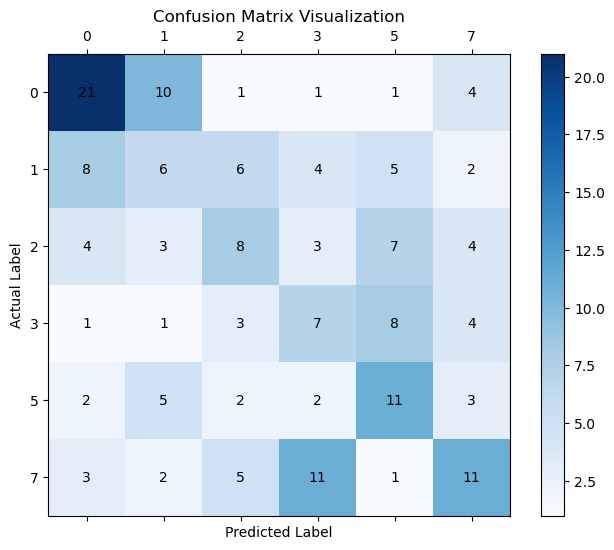

In [476]:
display_confusion_matrix(y_test, predictions, selected_classes)

# Saving Results

In [469]:
actual=np.array(y_test)
pred=np.array(predictions)

In [470]:
correctness=[]
for i in range(y_test.shape[0]):
    if actual[i]==pred[i]:
        correctness.append("Correct")
    else:
        correctness.append("Incorrect")

In [471]:
results={}
results['filename'] = filtered_df.loc[test_idx, 'Path']
results['ground_truth'] = actual
results['predictions'] = pred
results['correct'] = correctness

In [472]:
results=pd.DataFrame(results)

In [473]:
results

,filename,ground_truth,predictions,correct
110,Train/1/00001_00051_00024.png,1,1,Correct
419,Train/5/00005_00046_00009.png,5,5,Correct
565,Train/7/00007_00006_00018.png,7,7,Correct
77,Train/0/00000_00005_00020.png,0,1,Incorrect
181,Train/1/00001_00027_00009.png,1,0,Incorrect
...,...,...,...,...
54,Train/0/00000_00000_00019.png,0,1,Incorrect
493,Train/5/00005_00044_00013.png,5,1,Incorrect
46,Train/0/00000_00005_00006.png,0,0,Correct
93,Train/0/00000_00002_00025.png,0,0,Correct


In [474]:
results.to_csv("Results.csv")